# Example 5 — Derating (Pitch Control / Downregulation)

This notebook demonstrates the derating feature in WindGym.

> **Note — legacy approach.** This notebook uses the power-curve-inversion
> `DeratingModel` (`WindGym.core.derating`), which approximates derated Ct by
> moving down the turbine's normal operating curve. The preferred approach is a
> turbine built from a derating **surrogate** (power/ct tabulated over
> ws x yaw x derating, e.g. HAWCStab2-generated `PowerCtNDTabular`), which
> accepts `derate` natively and needs nothing from this module. `WindFarmEnv`
> only requires that the turbine's `powerCtFunction` accepts a `'derate'` input.  
Derating reduces a turbine's power output by moving its operating point to a lower wind speed on the P(ws) and Ct(ws) curves — this is physically correct because:

- `ws_op < ws_eff` → lower `Ct` → smaller wake deficit downstream
- Both power and thrust follow the turbine's own aerodynamics, not an arbitrary scaling

**Layout used here:** 3 SWT-2.3 turbines placed *side by side* (laterally separated, 5D spacing), so they do not wake each other.  
Wind blows straight at all three turbines.  Three derating levels are applied: 0 %, 50 %, 100 %.

This isolates the per-turbine effect — power and Ct each decrease monotonically, and the flow map shows three independent wakes that shrink with higher derating.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from py_wake.examples.data.lillgrund import SWT23
from py_wake.literature.gaussian_models import Blondel_Cathelain_2020
from py_wake.turbulence_models import STF2017TurbulenceModel
from py_wake.deflection_models.jimenez import JimenezWakeDeflection
from py_wake.site import UniformSite
from py_wake import HorizontalGrid

from WindGym.core.derating import add_derating_to_turbine

## 1. Build a derate-enabled SWT-2.3 turbine

`add_derating_to_turbine` attaches a `DeratingModel` to the turbine's `powerCtFunction`.  
After this, any call to `turbine.power(ws, derate=…)` or `turbine.ct(ws, derate=…)` uses the physically correct operating-point inversion.

In [10]:
wt = SWT23()
add_derating_to_turbine(wt)

print("optional_inputs after derating:", wt.powerCtFunction.optional_inputs)

optional_inputs after derating: ['Air_density', 'derate', 'tilt', 'yaw']


## 2. Power and Ct vs derating level

Sweep `derate` from 0 to 1 at a fixed inflow of 9 m/s to see how power and Ct vary.

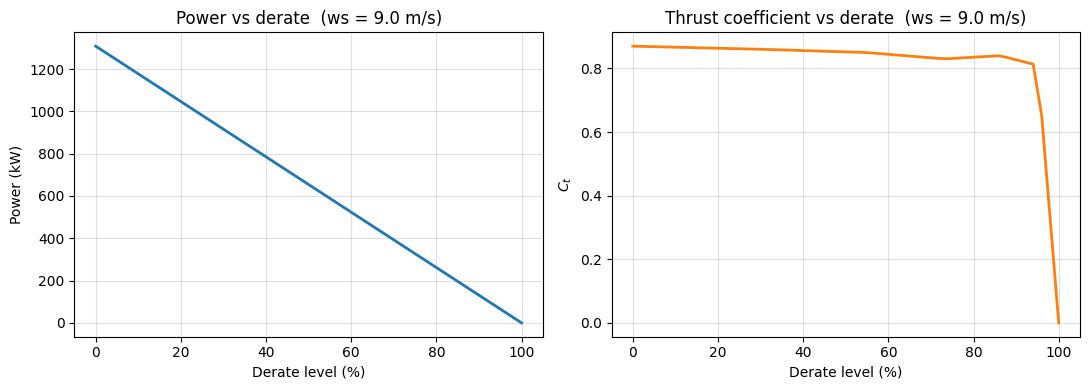

In [11]:
ws_fixed = 9.0
derate_sweep = np.linspace(0, 1, 51)

ws_arr = np.full_like(derate_sweep, ws_fixed)
P_sweep = wt.power(ws_arr, derate=derate_sweep) / 1e3   # kW
Ct_sweep = wt.ct(ws_arr, derate=derate_sweep)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(derate_sweep * 100, P_sweep, 'C0', lw=2)
axes[0].set_xlabel("Derate level (%)")
axes[0].set_ylabel("Power (kW)")
axes[0].set_title(f"Power vs derate  (ws = {ws_fixed} m/s)")
axes[0].grid(True, alpha=0.4)

axes[1].plot(derate_sweep * 100, Ct_sweep, 'C1', lw=2)
axes[1].set_xlabel("Derate level (%)")
axes[1].set_ylabel("$C_t$")
axes[1].set_title(f"Thrust coefficient vs derate  (ws = {ws_fixed} m/s)")
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## 3. Three-turbine side-by-side layout

Three turbines are placed 5 rotor diameters apart in the cross-wind direction (y-axis).  
Wind blows from the west (270°) so no turbine wakes another.

| Turbine | Derate |
|---------|--------|
| T0 | 0 %   (full power) |
| T1 | 50 %  (half power) |
| T2 | 100 % (full shutdown) |

In [12]:
D = wt.diameter()          # 93 m
WS = 9.0                   # inflow wind speed [m/s]
WD = 270.0                 # wind direction [deg]
TI = 0.06

# Side-by-side: all at x=0, separated laterally
x_pos = np.array([0.0, 0.0, 0.0])
y_pos = np.array([0.0, 5 * D, 10 * D])

derate_levels = np.array([0.0, 0.5, 1.0])
labels = [f"T{i}  (derate={d:.0%})" for i, d in enumerate(derate_levels)]

site = UniformSite(p_wd=[1.0], ti=TI)
model = Blondel_Cathelain_2020(
    site=site,
    windTurbines=wt,
    turbulenceModel=STF2017TurbulenceModel(),
    deflectionModel=JimenezWakeDeflection(),
)

sim = model(x_pos, y_pos, wd=[WD], ws=[WS], TI=TI, tilt=0,
            yaw=np.zeros(3), derate=derate_levels)

P_kw  = sim.power_ilk[:, 0, 0] / 1e3
Ct    = sim.ct_ilk[:, 0, 0]
ws_eff = sim.WS_eff_ilk[:, 0, 0]

print(f"{'Turbine':<30} {'P (kW)':>8} {'Ct':>6} {'ws_eff (m/s)':>12}")
print("-" * 60)
for i, lbl in enumerate(labels):
    print(f"{lbl:<30} {P_kw[i]:>8.1f} {Ct[i]:>6.3f} {ws_eff[i]:>12.2f}")


Turbine                          P (kW)     Ct ws_eff (m/s)
------------------------------------------------------------
T0  (derate=0%)                  1308.0  0.870         9.00
T1  (derate=50%)                  654.0  0.852         9.00
T2  (derate=100%)                   0.0  0.000         9.00


## 4. Power and Ct bar charts

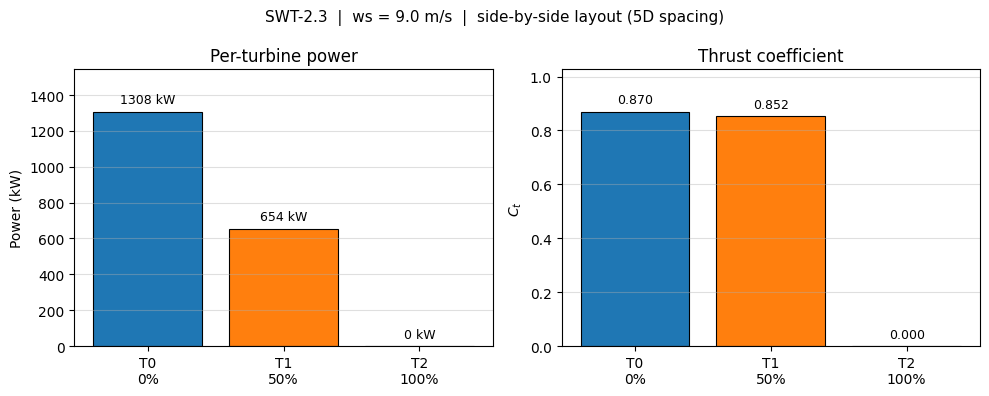

In [13]:
colors = ['C0', 'C1', 'C3']
x_ticks = np.arange(3)
short_labels = [f"T{i}\n{d:.0%}" for i, d in enumerate(derate_levels)]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

bars = axes[0].bar(x_ticks, P_kw, color=colors, edgecolor='k', linewidth=0.8)
axes[0].bar_label(bars, fmt='%.0f kW', padding=4, fontsize=9)
axes[0].set_xticks(x_ticks)
axes[0].set_xticklabels(short_labels)
axes[0].set_ylabel("Power (kW)")
axes[0].set_title("Per-turbine power")
axes[0].set_ylim(0, P_kw.max() * 1.18)
axes[0].grid(axis='y', alpha=0.4)

bars2 = axes[1].bar(x_ticks, Ct, color=colors, edgecolor='k', linewidth=0.8)
axes[1].bar_label(bars2, fmt='%.3f', padding=4, fontsize=9)
axes[1].set_xticks(x_ticks)
axes[1].set_xticklabels(short_labels)
axes[1].set_ylabel("$C_t$")
axes[1].set_title("Thrust coefficient")
axes[1].set_ylim(0, Ct.max() * 1.18)
axes[1].grid(axis='y', alpha=0.4)

fig.suptitle(f"SWT-2.3  |  ws = {WS} m/s  |  side-by-side layout (5D spacing)",
             fontsize=11)
plt.tight_layout()
plt.show()

## 5. Flow map — three independent wakes

The wake of each turbine shrinks as derating increases because `Ct` decreases.  
With full shutdown (T2), there is almost no wake visible.

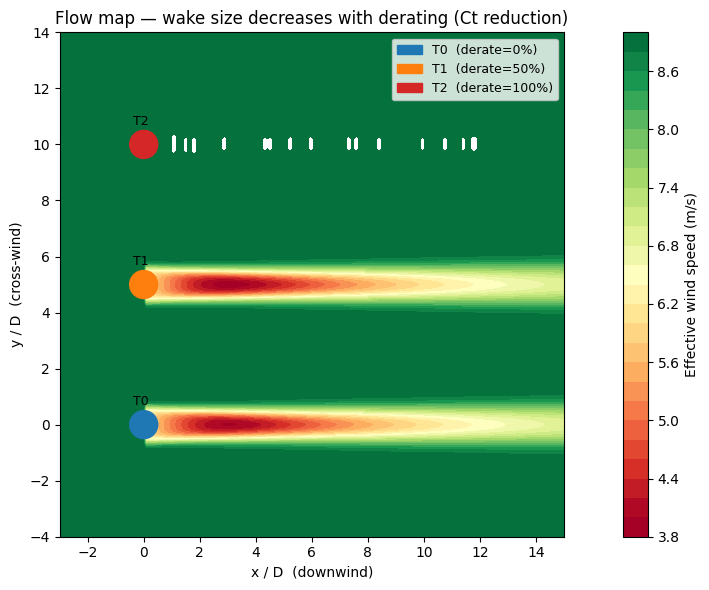

In [14]:
x_grid = np.linspace(-3 * D, 15 * D, 200)
y_grid = np.linspace(-4 * D, 10 * D + 4 * D, 200)

grid = HorizontalGrid(x=x_grid, y=y_grid, h=wt.hub_height())
fm = sim.flow_map(grid=grid)

ws_field = fm.WS_eff.squeeze().values  # (y, x)

fig, ax = plt.subplots(figsize=(12, 6))
cf = ax.contourf(x_grid / D, y_grid / D, ws_field,
                 levels=30, cmap='RdYlGn', vmin=4, vmax=WS)
plt.colorbar(cf, ax=ax, label='Effective wind speed (m/s)')

for i, (xi, yi, lbl, clr) in enumerate(zip(x_pos, y_pos, labels, colors)):
    circle = plt.Circle((xi / D, yi / D), 0.5, color=clr, fill=True, zorder=5, label=lbl)
    ax.add_patch(circle)
    ax.text(xi / D - 0.1, yi / D + 0.7, f"T{i}", color='k', fontsize=9, ha='center')

ax.set_xlabel("x / D  (downwind)")
ax.set_ylabel("y / D  (cross-wind)")
ax.set_title("Flow map — wake size decreases with derating (Ct reduction)")
ax.legend(loc='upper right', fontsize=9)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 5b. Same layout at rated wind speed — dramatic $C_T$ variation

At **below-rated** wind speed (Section 5a, 9 m/s) the SWT-2.3's $C_T$ is nearly flat (~0.87)
for all derate levels, so the three wakes look almost identical.

At **rated wind speed (13 m/s)** the same side-by-side layout tells a completely different story.
The underated turbine pitches heavily to cap power, dropping $C_T$ to **0.34** — a very weak wake.
The 30 % derated turbine returns to the high-induction region with $C_T$ **0.82** — a strong wake.
The fully shut-down turbine has $C_T$ **0.00** — no wake at all.

The three wakes are now clearly distinct in size, even though the layout is identical to Section 5a.

**Key insight:** the *operating regime* (below vs. at/above rated) determines whether derating
produces a visible wake change — not the curtailment level alone.

Turbine                          P (kW)     Ct
----------------------------------------------
T0  (derate=0%)                  2283.0  0.340
T1  (derate=30%)                 1598.1  0.819
T2  (derate=80%)                  456.6  0.839


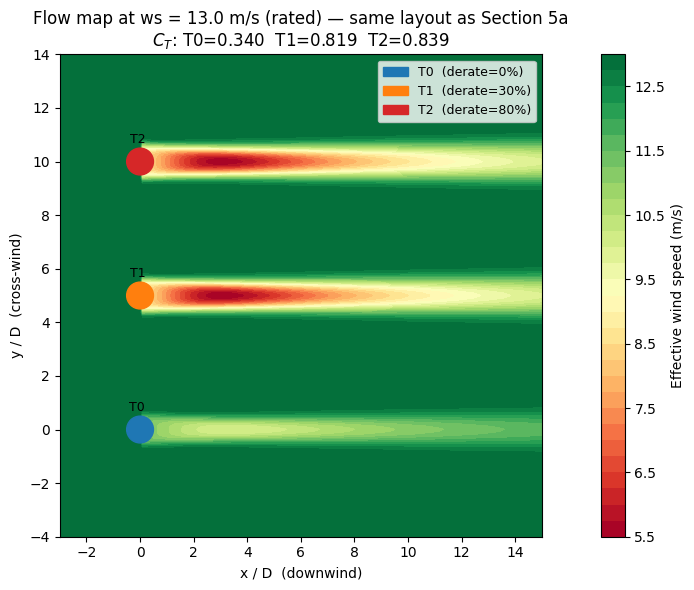

In [19]:
WS_rated = 13.0
TI_rated = 0.06

# Same side-by-side layout as Section 5a — T0=0%, T1=30%, T2=100% derate
derate_rated = np.array([0.0, 0.3, 0.8])
labels_rated = [f"T{i}  (derate={d:.0%})" for i, d in enumerate(derate_rated)]

sim_rated = model(x_pos, y_pos, wd=[WD], ws=[WS_rated], TI=TI_rated, tilt=0,
                  yaw=np.zeros(3), derate=derate_rated)

P_kw_r  = sim_rated.power_ilk[:, 0, 0] / 1e3
Ct_r    = sim_rated.ct_ilk[:, 0, 0]

print(f"{'Turbine':<30} {'P (kW)':>8} {'Ct':>6}")
print("-" * 46)
for i, lbl in enumerate(labels_rated):
    print(f"{lbl:<30} {P_kw_r[i]:>8.1f} {Ct_r[i]:>6.3f}")

x_grid_r = np.linspace(-3 * D, 15 * D, 200)
y_grid_r = np.linspace(-4 * D, 10 * D + 4 * D, 200)
grid_r   = HorizontalGrid(x=x_grid_r, y=y_grid_r, h=wt.hub_height())
fm_r     = sim_rated.flow_map(grid=grid_r)
ws_field_r = fm_r.WS_eff.squeeze().values

fig, ax = plt.subplots(figsize=(12, 6))
# Use the actual data minimum so even the weak T0 wake (Ct=0.34) is visible
cf = ax.contourf(x_grid_r / D, y_grid_r / D, ws_field_r,
                 levels=30, cmap='RdYlGn', vmin=ws_field_r.min(), vmax=WS_rated)
plt.colorbar(cf, ax=ax, label='Effective wind speed (m/s)')

for i, (xi, yi, lbl, clr) in enumerate(zip(x_pos, y_pos, labels_rated, colors)):
    ax.add_patch(plt.Circle((xi / D, yi / D), 0.5, color=clr, zorder=5, label=lbl))
    ax.text(xi / D - 0.1, yi / D + 0.7, f"T{i}", color='k', fontsize=9, ha='center')

ax.set_xlabel("x / D  (downwind)")
ax.set_ylabel("y / D  (cross-wind)")
ax.set_title(f"Flow map at ws = {WS_rated} m/s (rated) — same layout as Section 5a\n"
             f"$C_T$: T0={Ct_r[0]:.3f}  T1={Ct_r[1]:.3f}  T2={Ct_r[2]:.3f}")
ax.legend(loc='upper right', fontsize=9)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


In [ ]:
from PIL import Image
from WindGym import WindFarmEnv

env_config_rated = {
    'derate_action': True,
    'derate_min': 0.0,
    'derate_max': 1.0,
    'ActionMethod': 'wind',
    'farm': {'yaw_min': -30, 'yaw_max': 30},
    'wind': {'ws_min': 13., 'ws_max': 13., 'TI_min': 0.06, 'TI_max': 0.06,
             'wd_min': 270., 'wd_max': 270.},
    'act_pen': {'action_penalty': 0.0, 'action_penalty_type': 'change'},
    'power_def': {'Power_reward': 'Power_avg', 'Power_avg': 5, 'Power_scaling': 1.0},
    'mes_level': {'turb_ws': True, 'turb_wd': False, 'turb_TI': False, 'turb_power': False,
                  'farm_ws': False, 'farm_wd': False, 'farm_TI': False, 'farm_power': False},
    'ws_mes':    {'ws_current': True, 'ws_rolling_mean': False, 'ws_history_N': 1,
                  'ws_history_length': 10, 'ws_window_length': 10},
    'wd_mes':    {'wd_current': True, 'wd_rolling_mean': False, 'wd_history_N': 1,
                  'wd_history_length': 10, 'wd_window_length': 10},
    'yaw_mes':   {'yaw_current': True, 'yaw_rolling_mean': False, 'yaw_history_N': 1,
                  'yaw_history_length': 10, 'yaw_window_length': 10},
    'power_mes': {'power_current': False, 'power_rolling_mean': False, 'power_history_N': 1,
                  'power_history_length': 10, 'power_window_length': 10},
}

env_gif = WindFarmEnv(
    turbine=add_derating_to_turbine(SWT23()),
    x_pos=x_pos,
    y_pos=y_pos,
    config=env_config_rated,
    turbtype='Random',
    n_passthrough=5,
    render_mode='rgb_array',
    reset_init=False,
)

obs, info = env_gif.reset(seed=42)

# Action layout: [yaw_0, yaw_1, yaw_2,  derate_0, derate_1, derate_2]
# derate in [-1, 1]: -1→0%,  -0.4→30%,  +1→100%
#
# Mirrors the static plot above: T0=0%, T1=30%, T2=100% derate
#   T0 (0% derate)  → Ct=0.34 (pitch-regulated at rated) → WEAK wake
#   T1 (30% derate) → Ct=0.82 (moved back to below-rated region) → STRONG wake
#   T2 (100% derate)→ Ct=0    (shutdown) → NO wake
#
# NOTE: at rated wind speed the *underated* turbine (T0) shows the weakest wake
# because pitch control keeps power constant at the cost of very low thrust.
action_gif = np.array([0., 0., 0.,  -1., 0.85, 0.9])

frames_gif = []
for _ in range(160):
    obs, reward, terminated, truncated, info = env_gif.step(action_gif)
    frames_gif.append(env_gif.render())

env_gif.close()

out_gif = "derating_flow.gif"
pil_frames = [Image.fromarray(f) for f in frames_gif]
pil_frames[0].save(
    out_gif,
    save_all=True,
    append_images=pil_frames[1:],
    duration=100,   # ms per frame → 10 fps
    loop=0,
)
print(f"Saved {len(frames_gif)} frames → {out_gif}")
print("T0 (derate=0%): Ct≈0.34  — weak wake  (pitch-regulated at rated)")
print("T1 (derate=30%): Ct≈0.82 — strong wake (below-rated operating point)")
print("T2 (derate=100%): Ct=0   — no wake     (shutdown)")


Saved 160 frames → derating_flow.gif
T0 (derate=0%): Ct≈0.34  — weak wake  (pitch-regulated at rated)
T1 (derate=30%): Ct≈0.82 — strong wake (below-rated operating point)
T2 (derate=100%): Ct=0   — no wake     (shutdown)


## 6. Using derating inside the WindFarmEnv (RL setting)

To enable derating in a `WindFarmEnv`, add `derate_action: true` to the config.
The turbine passed to the env must accept a `'derate'` input — either natively
(surrogate-based) or via the legacy wrapper: `add_derating_to_turbine(SWT23())`.  
The action space doubles: `[yaw_0..yaw_n | derate_0..derate_n]`, each in `[-1, 1]`.  
The derate part maps `[-1, 1] → [derate_min, derate_max]` (default `[0, 1]`).

The examples below use the **Dynamiks** backend (default), so turbulence is time-varying  
and stepping the environment forward genuinely evolves the flow field.

In [17]:
from WindGym import WindFarmEnv

env_config = {
    'derate_action': True,
    'derate_min': 0.0,
    'derate_max': 1.0,
    'ActionMethod': 'wind',
    'farm': {'yaw_min': -30, 'yaw_max': 30},
    'wind': {'ws_min': 7, 'ws_max': 11, 'TI_min': 0.04, 'TI_max': 0.1,
             'wd_min': 268, 'wd_max': 272},
    'act_pen': {'action_penalty': 0.0, 'action_penalty_type': 'change'},
    'power_def': {'Power_reward': 'Power_avg', 'Power_avg': 5, 'Power_scaling': 1.0},
    'mes_level': {'turb_ws': True, 'turb_wd': False, 'turb_TI': False, 'turb_power': False,
                  'farm_ws': False, 'farm_wd': False, 'farm_TI': False, 'farm_power': False},
    'ws_mes':    {'ws_current': True,    'ws_rolling_mean': False,    'ws_history_N': 1,
                  'ws_history_length': 10,  'ws_window_length': 10},
    'wd_mes':    {'wd_current': True,    'wd_rolling_mean': False,    'wd_history_N': 1,
                  'wd_history_length': 10,  'wd_window_length': 10},
    'yaw_mes':   {'yaw_current': True,   'yaw_rolling_mean': False,   'yaw_history_N': 1,
                  'yaw_history_length': 10, 'yaw_window_length': 10},
    'power_mes': {'power_current': False,'power_rolling_mean': False,  'power_history_N': 1,
                  'power_history_length': 10,'power_window_length': 10},
}

env = WindFarmEnv(
    turbine=add_derating_to_turbine(SWT23()),
    x_pos=np.array([0.0, 0.0, 0.0]),
    y_pos=np.array([0.0, 5 * D, 10 * D]),
    config=env_config,
    # backend='dynamiks' is the default — Dynamiks uses time-varying turbulence
    turbtype='Random',
    n_passthrough=5,
    reset_init=False,
)

obs, info = env.reset(seed=7)

print("Action space (yaw + derate):", env.action_space)
print()

# Apply: yaw=0 for all, derate=[0, 0.5, 1.0]
# Action layout: [yaw_0, yaw_1, yaw_2,  derate_0, derate_1, derate_2]
# derate in [-1, 1]: -1→0%,  0→50%,  +1→100%
action = np.array([0.0, 0.0, 0.0,  -1.0, 0.0, 1.0])
obs, reward, terminated, truncated, info = env.step(action)

print(f"{'':30} {'T0':>8} {'T1':>8} {'T2':>8}")
print(f"{'Derate fraction':30} {info['derate agent'][0]:>8.2f} {info['derate agent'][1]:>8.2f} {info['derate agent'][2]:>8.2f}")
print(f"{'Power (kW)':30} {info['Power pr turbine agent'][0]/1e3:>8.1f} {info['Power pr turbine agent'][1]/1e3:>8.1f} {info['Power pr turbine agent'][2]/1e3:>8.1f}")
print(f"{'Reward':30} {reward:>8.4f}")

env.close()

Action space (yaw + derate): Box(-1.0, 1.0, (6,), float32)

                                     T0       T1       T2
Derate fraction                    0.00     0.50     1.00
Power (kW)                       1521.1    766.8      0.0
Reward                           0.8904


## 7. WindGym flow visualisation with derating

Capture frames via `render_mode='rgb_array'` and `env.render()` at each step,  
then write them to an MP4 with `imageio`.  
With the Dynamiks backend the DWM particles evolve each step, so the video  
shows the turbulent wake developing over time.

In [18]:
import cv2
import subprocess
import tempfile
import os

env_render = WindFarmEnv(
    turbine=add_derating_to_turbine(SWT23()),
    x_pos=np.array([0.0, 0.0, 0.0]),
    y_pos=np.array([0.0, 5 * D, 10 * D]),
    config=env_config,
    turbtype='Random',
    n_passthrough=5,
    render_mode='rgb_array',
    reset_init=False,
)

obs, info = env_render.reset(seed=7)

# Action layout: [yaw_0, yaw_1, yaw_2,  derate_0, derate_1, derate_2]
# derate in [-1, 1]: -1→0%,  0→50%,  +1→100%
action = np.array([0.0, 0.0, 0.0,  -1.0, 0.0, 1.0])

frames = []
N_steps = 200
for _ in range(N_steps):
    obs, reward, terminated, truncated, info = env_render.step(action)
    frames.append(env_render.render())   # (H, W, 3) uint8 RGB

env_render.close()

fps = 10
out_path = "derating_flow.mp4"

H, W = frames[0].shape[:2]
# yuv420p requires even dimensions
W_even = W + W % 2
H_even = H + H % 2

with tempfile.NamedTemporaryFile(suffix='.raw', delete=False) as tmp:
    tmp_path = tmp.name
    for frame in frames:
        bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        if W_even != W or H_even != H:
            bgr = cv2.copyMakeBorder(bgr, 0, H_even - H, 0, W_even - W,
                                     cv2.BORDER_CONSTANT, value=0)
        tmp.write(bgr.tobytes())

subprocess.run([
    'ffmpeg', '-y',
    '-f', 'rawvideo', '-pixel_format', 'bgr24',
    '-video_size', f'{W_even}x{H_even}', '-framerate', str(fps),
    '-i', tmp_path,
    '-vcodec', 'libx264', '-profile:v', 'baseline', '-level', '3.0',
    '-pix_fmt', 'yuv420p',
    out_path,
], check=True)

os.unlink(tmp_path)
print(f"Saved {len(frames)} frames → {out_path}")

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

Saved 200 frames → derating_flow.mp4


[out#0/mp4 @ 0x5c0d3659ab00] video:14358kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.011610%
frame=  200 fps=117 q=-1.0 Lsize=   14360kB time=00:00:19.90 bitrate=5911.3kbits/s speed=11.6x    
[libx264 @ 0x5c0d3659c200] frame I:1     Avg QP:21.22  size: 90806
[libx264 @ 0x5c0d3659c200] frame P:199   Avg QP:25.49  size: 73423
[libx264 @ 0x5c0d3659c200] mb I  I16..4: 37.6%  0.0% 62.4%
[libx264 @ 0x5c0d3659c200] mb P  I16..4: 10.5%  0.0% 32.7%  P16..4:  4.5%  8.8%  7.4%  0.0%  0.0%    skip:36.0%
[libx264 @ 0x5c0d3659c200] coded y,uvDC,uvAC intra: 98.2% 98.3% 98.3% inter: 30.6% 32.6% 30.2%
[libx264 @ 0x5c0d3659c200] i16 v,h,dc,p:  6%  5% 75% 14%
[libx264 @ 0x5c0d3659c200] i4 v,h,dc,ddl,ddr,vr,hd,vl,hu: 15% 20% 27%  6%  7%  5%  7%  5%  8%
[libx264 @ 0x5c0d3659c200] i8c dc,h,v,p: 72% 10%  5% 13%
[libx264 @ 0x5c0d3659c200] ref P L0: 41.8% 29.8% 28.4%
[libx264 @ 0x5c0d3659c200] kb/s:5880.76
